# Working with `FluidMidi` objects

## Introduction

`FluidMidi` is a table data type able to represent any MIDI file. A MIDI file with extension '.mid' contains symbolic information of a musical performance with orchestraction, automation, and other signals.

To load a midi file simply call
```
table = midifile_load('path/to/midi_file.mid')
```
This reads the midi file, decodes it into a sequence of high level messages, and stores it in a structured array, `FluidMidi` object `table`.

It is also easy to store the musical data in a `FluidMidi` object to a midi file with
```
midifile_save_1(table, 'path/to/output/midi_file.mid')
```

This notebook demonstrates the structure and properties of the `FluidMidi` object and how to manipulate it.

In [1]:
# Required for midi visualizer
%matplotlib widget

In [2]:
import os
from pathlib import Path

## Imports

In [3]:
from fluidmidi import *
from fluidmidi.midi_visualizer import visualize_fluidmidi
from fluidmidi.analysis import *
from fluidmidi.web_player import load_web_midi_player, web_fluidmidi_player

In [4]:
## Locating midi files and soundfont files
# For the purpose of this experiment we are looking for midi files and 
# soundfont files in the user's default downloads folder.
path = Path('~/Downloads').expanduser()
for file in os.listdir(path):
    if file.lower().endswith('.mid'):  # change this to '.sf2' for find soundfont files
        print(file)

eulogy.mid
SweetWay1.mid
midi_test-2-tracks-type-0.mid
09-tool_2001-lateralus.mid
LetItBe.mid
12bar1.mid
somebody_else_is_taking_my_place-1942-kar_jpp.mid
concerto_11_1_(c)oguri.mid
OpenCar.mid
Jackson_5_-_Dancing_Machine.mid
Tripping7.mid
12bar1 (1).mid
HereWithoutYou.mid
Queen_-_Bohemian_Rhapsody.mid
Fairy Tail - Main Theme (Piano Ver).mid
StillGotTheBlues.mid
deadwing.mid


In [5]:
# Change these to file names that you have
sff = path / 'WINLITE.SF2'
mf = path / 'LetItBe.mid'

## Synthsizer setup

We will use the web midi player to play the fluidmidi table. This should also work in a Colab notebook.

In [6]:
# Run this once to initialize the web midi player
load_web_midi_player()

## Loading the midi file

In [7]:
table = midifile_load(str(mf))
lt1k = table[table['time'] <= 3000]
print(type(table), table)
lt1k.print()                         # `.print() method prints the messages in a readable manner with color coding

<class 'fluidmidi.pyside.midi.FluidMidi'> <fluidmidi.pyside.midi.FluidMidi object at 0x1179c50c0>
0 TSIG:	TIME_SIGNATURE		4 | 4		0x58 [0, 0]
0 META:	KEY_SIGNATURE		(00 00 )			0x59 [0, 0]
0 TEMPO:	TEMPO_SET		tempo = 70.00 bpm		0x51 [0, 0]
0 META:	MARKER		'*** Let It Be ***'			0x06 [0, 0]
0 META:	MARKER		'by The Beatles'			0x06 [0, 0]
0 META:	MIDI_PORT		(00 )			0x21 [1, 0]
0 TRACK:	TRACK_NAME		'Soft Karaoke'			0x03 [1, 0]
0 META:	TEXT		'@KMIDI KARAOKE FILE'			0x01 [1, 0]
0 META:	TEXT		'@V0100'			0x01 [1, 0]
0 META:	TEXT		'@I Lyrics entered by Raphael Pungin'			0x01 [1, 0]
0 META:	TEXT		'@I email: br326@cleveland.freenet.edu'			0x01 [1, 0]
0 EOT:	END_OF_TRACK		()			0x2F [1, 0]
0 META:	MIDI_PORT		(00 )			0x21 [2, 0]
0 TRACK:	TRACK_NAME		'Words'			0x03 [2, 0]
0 META:	TEXT		'@LENGL'			0x01 [2, 0]
0 META:	TEXT		'@TLET IT BE'			0x01 [2, 0]
0 META:	TEXT		'@TThe Beatles'			0x01 [2, 0]
0 META:	MIDI_PORT		(00 )			0x21 [3, 0]
0 TRACK:	TRACK_NAME		'Melody'			0x03 [3, 0]
0 PC:	103	FX 8 (sci-fi)		0xC0

## Structure of `FluidMidi`

FluidMidi is a container of a numpy structured array with the following columns
- `time` - Stores the absolute time of the event in units of MIDI ticks. [What are MIDI ticks? (See `mido` docs)](https://mido.readthedocs.io/en/1.3.1/files/midi.html#about-the-time-attribute)
- `track` - The track number of a message. Track names are usually given as `TrackName` meta messages.
- `channel` - The MIDI channel of the message. There are 16 channels in a MIDI port (0-15).
- `mtype` - An enum value representing the type of the message. See `Mtype` below
- `status` - Used internally to decode and encode binary MIDI
- `program` - Program number of a program change message
- `control` - Control number of a control change message
- `cc_val` - The value to set for the control in a control change message
- `note_val` - The note number of the note on message. Note value 60 = C4 (middle C)
- `note_vel` - The velocity of the note on event. Represents the force of sounding the note.
- `midi_d` - The duration of the note on event in midi ticks.
- `score_d` - Unused.
- `pitch` - The pitch bend value of a pitch bend event.
- `delta` - The delta time duration of the event. Used internally.
- `data` - Don't touch this. Used internally.

## `Mtype`
The 'mtype' column can contain the following enum values corresponding to the type of the MIDI message

- EMPTY - An undefined row with no data
- META - An uncategorized Meta message
- TEMPO - A tempo change meta message
- TSIG - A time signature change meta message
- TRACK - Track name meta message for the track number of the message
- SYSEX - A System-Exclusive message
- ESCAPE - A special purpose message
- PC - A Program change message that changes the channel instrument of the synthesizer
- CC - A control change message that can alter any of 128 parameters including volume, pan, reverb, etc of a channel
- POLYP
- CHANP
- CHAN - Placeholder. Unused.
- BEND1 - A note bend message with alters the pitch
- NOF - A note off message corresponding to the note on message of the same note value.
- BEND0 - A note bend message for no bend
- NON - A note on message. Contains note value, note velocity, note duration
- EOT - An End-of-track meta message for the corresponding track number.

In [8]:
# The raw array can be accessed with the member. But this should not be necessary to use
table.ndarray

array([(     0,  0, 0,  3, 88, 4, 4, 24, 8, 0, 0, 0,      0,    0, 105553176190112),
       (     0,  0, 0,  1, 89, 0, 0,  0, 0, 0, 0, 0,      0,    0, 105553176190080),
       (     0,  0, 0,  2, 81, 0, 0,  0, 0, 0, 0, 0, 857142,    0, 105553176190048),
       ...,
       (138240, 10, 0, 17, 47, 0, 0,  0, 0, 0, 0, 0,      0,    0, 105553176906112),
       (142565,  0, 0,  1,  6, 0, 0,  0, 0, 0, 0, 0,      0, 4325, 105553176190400),
       (142565,  0, 0, 17, 47, 0, 0,  0, 0, 0, 0, 0,      0,    0, 105553176190432)],
      shape=(7089,), dtype={'names': ['time', 'track', 'channel', 'mtype', 'status', 'program', 'control', 'cc_val', 'noteval', 'notevel', 'midi_d', 'score_d', 'pitch', 'delta', 'data'], 'formats': ['<i4', 'u1', 'u1', 'u1', 'u1', 'u1', 'u1', 'u1', 'u1', 'u1', '<u4', '<u4', '<i4', '<u4', '<u8'], 'offsets': [0, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16, 20, 24, 28, 32], 'itemsize': 40, 'aligned': True})

## Extracting data from `FluidMidi` objects

FluidMidi enables logical indexing to filter, extract, and modify data in the table.

In [9]:
allnotes = table[table['mtype'] == Mtype.NON]  # Extract the note-on messages
drums    = allnotes[allnotes['channel'] == 9]  # Collect all notes from the drum channel
others   = allnotes[allnotes['channel'] != 9]  # Get all other instrument channels
lt5k     = drums[drums['time'] < 400000]       # Extract all notes before time in ticks
lt5k.print()

47280 NON:	5	38	110			0x90 [11, 9]
47400 NON:	5	45	110			0x90 [11, 9]
47520 NON:	5	45	110			0x90 [11, 9]
47640 NON:	5	45	110			0x90 [11, 9]
47760 NON:	5	38	110			0x90 [11, 9]
47880 NON:	5	45	110			0x90 [11, 9]
48000 NON:	5	36	100			0x90 [11, 9]
48000 NON:	5	49	110			0x90 [11, 9]
48240 NON:	5	42	127			0x90 [11, 9]
48480 NON:	5	38	110			0x90 [11, 9]
48480 NON:	5	42	127			0x90 [11, 9]
48720 NON:	5	42	127			0x90 [11, 9]
48960 NON:	5	36	100			0x90 [11, 9]
48960 NON:	5	42	127			0x90 [11, 9]
49200 NON:	5	36	100			0x90 [11, 9]
49200 NON:	5	42	127			0x90 [11, 9]
49440 NON:	5	38	110			0x90 [11, 9]
49440 NON:	5	42	127			0x90 [11, 9]
49680 NON:	5	42	127			0x90 [11, 9]
49920 NON:	5	42	127			0x90 [11, 9]
49920 NON:	5	36	100			0x90 [11, 9]
50160 NON:	5	42	127			0x90 [11, 9]
50400 NON:	5	46	115			0x90 [11, 9]
50400 NON:	5	38	110			0x90 [11, 9]
50640 NON:	5	42	127			0x90 [11, 9]
50880 NON:	5	36	100			0x90 [11, 9]
50880 NON:	5	42	127			0x90 [11, 9]
51120 NON:	5	42	127			0x90 [11, 9]
51360 NON:	5	38	110	

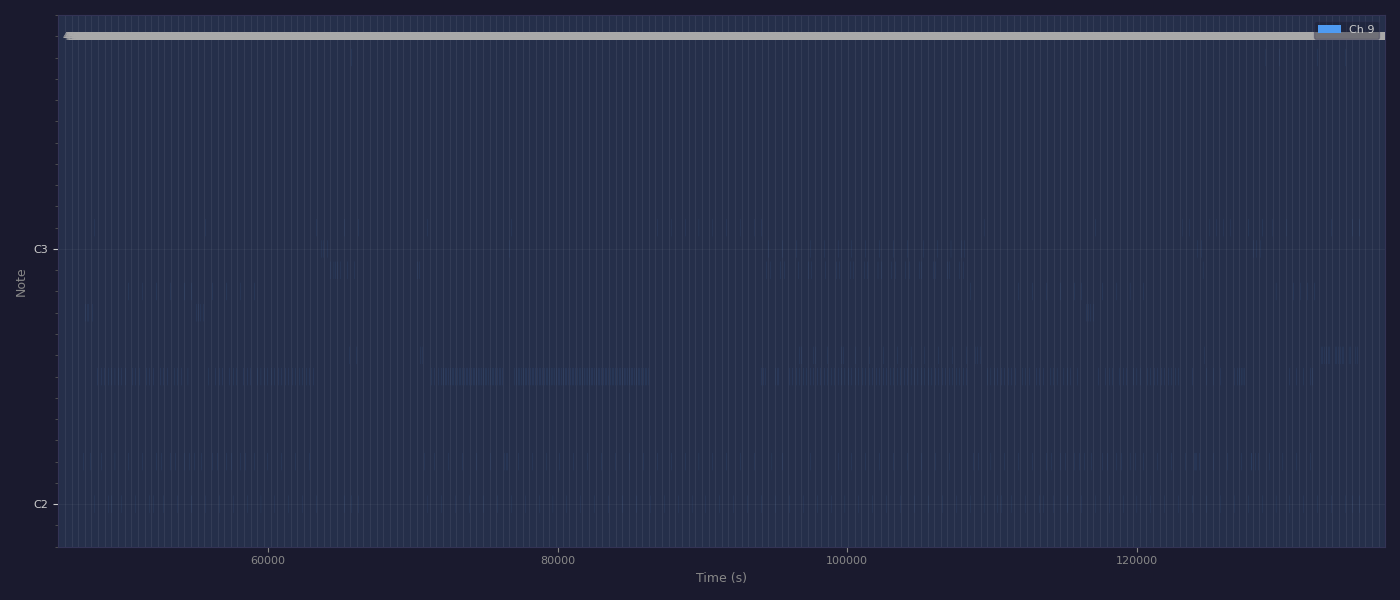

In [10]:
visualize_fluidmidi(drums)

### Getting tempo changes, and time signatures in a song

In [11]:
#Extract time signature information
tsig = table[table['mtype'] == Mtype.TSIG]
tsig.print()

0 TSIG:	TIME_SIGNATURE		4 | 4		0x58 [0, 0]


In [12]:
tempo = table[table['mtype'] == Mtype.TEMPO]
tempo.print()

0 TEMPO:	TEMPO_SET		tempo = 70.00 bpm		0x51 [0, 0]
132580 TEMPO:	TEMPO_SET		tempo = 67.00 bpm		0x51 [0, 0]
133225 TEMPO:	TEMPO_SET		tempo = 63.00 bpm		0x51 [0, 0]
133780 TEMPO:	TEMPO_SET		tempo = 60.00 bpm		0x51 [0, 0]
134240 TEMPO:	TEMPO_SET		tempo = 52.00 bpm		0x51 [0, 0]


These above are not very useful to get the relevant values. Utility functions are provided for this purpose

In [13]:
fluidmidi_get_tempo_changes(table)

array([[0.00000000e+00, 7.00000700e+01],
       [1.32580000e+05, 6.70000290e+01],
       [1.33225000e+05, 6.30000630e+01],
       [1.33780000e+05, 6.00000000e+01],
       [1.34240000e+05, 5.20000069e+01]])

In [14]:
fluidmidi_get_timesig_changes(table)

array([[0, 4, 4]], dtype=int32)

## How to think about rhythm in music

In [15]:
# Counting system
quarter = 480  # ticks
tsig_nume, tsig_deno = 4, 4

beat_dur = quarter * 4 / tsig_deno
subdivs = 3  # 2 for 8ths, 4 for 16th, etc
beats_in_bar = tsig_nume
bars_in_phrase = 4

In [16]:
bar_dur = beats_in_bar * beat_dur
phrase_dur = bar_dur * bars_in_phrase
subdiv_dur = beat_dur // subdivs

In [17]:
phrase_dur, bar_dur, beat_dur, subdiv_dur

(7680.0, 1920.0, 480.0, 160.0)

In [18]:
# times = drums['time']
times = np.arange(0, 128) * subdiv_dur
phrase = times // phrase_dur
res = times % phrase_dur
bar = res // bar_dur
res = res % bar_dur
beat = res // beat_dur
res = res % beat_dur
subdiv = res // subdiv_dur
res = res % subdiv_dur
data = np.vstack((phrase, bar, beat, subdiv, res))

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

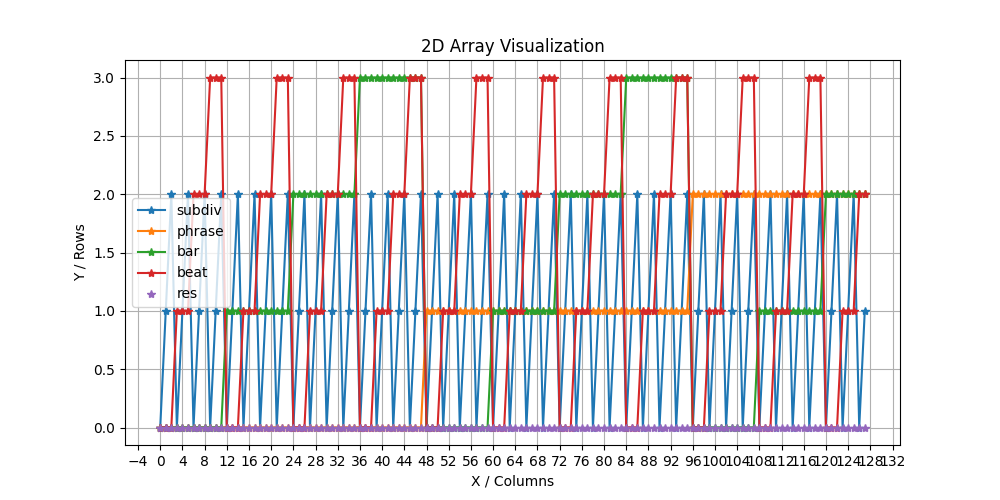

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("2D Array Visualization")
ax.set_xlabel("X / Columns")
ax.set_ylabel("Y / Rows")

ax.plot(subdiv, '*-')
ax.plot(phrase, '*-')
ax.plot(bar, '*-')
ax.plot(beat, '*-')
ax.plot(res / 20, '*')
plt.legend(['subdiv', 'phrase', 'bar', 'beat', 'res'])
ax.xaxis.set_major_locator(ticker.MultipleLocator(beats_in_bar))
# ax.plot(res)
plt.grid()
plt.show()

In [21]:
# Extracting time chunks
def logical_within_bounds(array, min, max):
    return (array >= min) & (array <= max)

In [22]:
bar1 = drums[logical_within_bounds(drums['time'], 0, bar_dur)]
bar2 = drums[logical_within_bounds(drums['time'], bar_dur, 2 * bar_dur)]

bar2.print()

bar2['time'] -= np.min(bar2['time'])
bar2

In [23]:
bar2.print()

In [24]:
web_fluidmidi_player(table, visualizer=False)

In [25]:
np.vstack((drums['time'], drums['noteval'], drums['notevel'])).T

array([[ 47280,     38,    110],
       [ 47400,     45,    110],
       [ 47520,     45,    110],
       ...,
       [135240,     43,    110],
       [135360,     36,    100],
       [135360,     49,    124]], shape=(654, 3), dtype=int32)